# 포즈 그대로, 인물은 다르게: OpenPose + ControlNet (FLUX.2-klein 4B) 로컬 실행

**목표**: 참조 사진 한 장에서 사람의 관절(포즈)만 뽑아내고, 그 포즈는 그대로 유지한 채 완전히 다른 인물/장면으로 새 이미지를 생성한다.

```
참조 사진 --(OpenPose)--> 관절 스켈레톤 --(ControlNet 조건)--> FLUX.2-klein 4B --(프롬프트)--> 새 인물/장면 이미지
```

**이 노트북은 Colab이 아니라 로컬 머신(Apple Silicon Mac, MPS)에서 실행한 것을 그대로 옮긴 것이다.**

과제 원문이 예시로 든 `FLUX.2-klein 4B`는 2026-09 기준 공식 ControlNet-OpenPose 체크포인트가 없다.
대신 [`DiffSynth-Studio/Template-KleinBase4B-ControlNet`](https://huggingface.co/DiffSynth-Studio/Template-KleinBase4B-ControlNet)이라는
커뮤니티(ModelScope/DiffSynth-Studio) 제작 ControlNet이 FLUX.2-klein-base-4B 아키텍처에 맞춰 학습되어 있어 이걸 사용했다.

**요구 사항**
- 디스크 약 24GB (transformer 7.75GB + text_encoder 8.04GB + vae 0.17GB + ControlNet 7.75GB)
- GPU 메모리(또는 Apple Silicon 통합 메모리) 32GB 이상 권장
- Apple Silicon이면 `device="mps"`, Nvidia GPU면 `device="cuda"`로 바꾸면 그대로 동작한다 (DiffSynth-Studio가 MPS를 공식 지원한다)

In [ ]:
# 필요한 라이브러리 설치
# - diffsynth       : FLUX.2-klein 4B + ControlNet 템플릿을 구동하는 파이프라인 본체 (ModelScope/DiffSynth-Studio)
# - controlnet_aux  : 참조 사진에서 OpenPose 스켈레톤을 뽑는 전처리기
!pip install -q "git+https://github.com/modelscope/DiffSynth-Studio.git"
!pip install -q controlnet_aux

## 0단계. 참조 사진 준비

포즈의 '기준'이 될 사람 사진 한 장을 로컬 경로에서 불러온다. `REFERENCE_IMAGE_PATH`를 원하는 사진으로 바꾸면 된다.

In [ ]:
import os
from PIL import Image

REFERENCE_IMAGE_PATH = "reference.jpg"  # 원하는 참조 사진 경로로 교체
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

reference_image = Image.open(REFERENCE_IMAGE_PATH).convert("RGB")
print("원본 크기:", reference_image.size)
reference_image

## 1단계. OpenPose로 관절 스켈레톤 추출

`controlnet_aux`의 기본 OpenPose(Body25/COCO) 모델을 사용한다.

**실제로 겪은 문제**: 팔다리가 심하게 겹치거나 얼굴이 가려지는 극단적인 무용 동작에서는
이 모델이 팔꿈치·손목 관절을 놓치는 경우가 있었다 (아래 '한계' 참고). 더 정확한 전신 검출이
필요하면 `controlnet_aux.DWposeDetector`를 쓸 수 있지만, mmcv/mmdet/mmpose 설치가 추가로
필요하고 Apple Silicon에서는 설치가 까다롭다(CUDA 전용 연산 다수).

In [ ]:
import numpy as np
from controlnet_aux import OpenposeDetector
from controlnet_aux.open_pose import draw_poses

detector = OpenposeDetector.from_pretrained("lllyasviel/ControlNet")
poses = detector.detect_poses(np.array(reference_image))
print("감지된 사람 수:", len(poses))

width, height = reference_image.size
pose_image = Image.fromarray(
    draw_poses(poses, height, width, draw_body=True, draw_hand=False, draw_face=False)
)

# FLUX.2 VAE는 16의 배수 해상도를 요구한다 (아니면 인코딩 단계에서 에러가 난다)
w16 = round(width / 16) * 16
h16 = round(height / 16) * 16
pose_image = pose_image.resize((w16, h16))

pose_image.save(os.path.join(OUTPUT_DIR, "pose_skeleton.png"))
pose_image

## 2단계. 모델 로드

세 가지를 불러온다.

1. **Flux2ImagePipeline** — FLUX.2-klein-base-4B 본체 (transformer + text encoder + VAE)
2. **TemplatePipeline** — `Template-KleinBase4B-ControlNet` 가중치. 참조 이미지를 VAE로 인코딩해
   KV-cache 형태로 만들고, 이걸 본체 트랜스포머의 attention에 주입하는 방식으로 '구조 조건'을 건다.

`model_id`만 주면 Hugging Face에서 자동으로 다운로드한다 (총 ~24GB, 시간이 좀 걸린다).

In [ ]:
import torch
from diffsynth.pipelines.flux2_image import Flux2ImagePipeline, ModelConfig
from diffsynth.diffusion.template import TemplatePipeline

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

pipe = Flux2ImagePipeline.from_pretrained(
    torch_dtype=torch.bfloat16,
    device=device,
    model_configs=[
        ModelConfig(model_id="black-forest-labs/FLUX.2-klein-base-4B", origin_file_pattern="transformer/*.safetensors"),
        ModelConfig(model_id="black-forest-labs/FLUX.2-klein-4B", origin_file_pattern="text_encoder/*.safetensors"),
        ModelConfig(model_id="black-forest-labs/FLUX.2-klein-4B", origin_file_pattern="vae/diffusion_pytorch_model.safetensors"),
    ],
    tokenizer_config=ModelConfig(model_id="black-forest-labs/FLUX.2-klein-4B", origin_file_pattern="tokenizer/"),
)

template = TemplatePipeline.from_pretrained(
    torch_dtype=torch.bfloat16,
    device=device,
    model_configs=[ModelConfig(model_id="DiffSynth-Studio/Template-KleinBase4B-ControlNet")],
)
print("모델 로드 완료")

## 3단계. 이미지 생성

포즈(스켈레톤)는 `template_inputs`로 고정한 채, 프롬프트로 완전히 다른 인물/장면을 묘사해서 새 이미지를 생성한다.

**핵심 교훈 (처음엔 실패했다)**: 이 ControlNet은 픽셀 단위로 자세를 강제하는 고전적 ControlNet과 달리,
참조 이미지를 KV-cache로 인코딩해 attention에 '참고 정보'로 얹는 방식이다. 그래서 프롬프트가
`portrait`, `bust shot`처럼 정적인 구도를 암시하는 단어를 쓰면 텍스트 쪽 힘이 더 세져서 포즈 조건이
거의 무시된다. **자세를 프롬프트에 직접 구체적으로 서술해야** 스켈레톤 조건과 시너지가 난다.

In [ ]:
POSE_DESC = (
    "full body shot, dynamic acrobatic dance pose, bent sharply forward at the waist, "
    "head tucked down between the legs, one arm raised straight overhead reaching upward with fingers spread, "
    "the other arm wrapped tightly around a bent knee lifted up toward the chest, "
    "balancing on one bare foot on tiptoe, muscular contorted twisting body, dramatic dance photography"
)

prompts = [
    f"A young woman ballet dancer in a flowing red dress, {POSE_DESC}, dramatic stage lighting",
    f"An elderly man in a tailored suit, {POSE_DESC}, dramatic black and white fine art photography",
    f"A futuristic humanoid robot made of chrome metal, {POSE_DESC}, dramatic rim lighting, cinematic sci-fi photography",
]

for i, prompt in enumerate(prompts, start=1):
    print(f"[{i}/{len(prompts)}] 생성 중: {prompt[:60]}...")
    image = template(
        pipe,
        prompt=prompt,
        seed=i * 100,
        cfg_scale=4,
        num_inference_steps=25,
        template_inputs=[{"image": pose_image, "prompt": prompt}],
        negative_template_inputs=[{"image": pose_image, "prompt": ""}],
    )
    out_path = os.path.join(OUTPUT_DIR, f"output_{i:02d}.png")
    image.save(out_path)
    print("저장:", out_path)

## 결과 및 한계

- 발레리나 / 노년 남성 / 로봇 세 가지 완전히 다른 인물·장면으로, 참조 사진과 같은
  "한 팔은 위로 뻗고 다른 팔은 굽힌 다리를 감싸는" 역동적 포즈를 재현했다 (`samples/` 폴더 참고).
- **한계 1 — OpenPose 관절 누락**: 참조 사진의 자세가 워낙 극단적(팔다리가 겹치고 얼굴이 가려짐)이라,
  기본 OpenPose(Body25/COCO) 모델이 양쪽 팔꿈치·손목·얼굴 관절을 전혀 검출하지 못했다.
  실제로 뽑힌 스켈레톤은 몸통·다리 관절만 남은 '부분 스켈레톤'이었다.
- **한계 2 — 소프트 컨디셔닝**: 이 ControlNet은 참조 이미지를 KV-cache로 인코딩해 attention에 얹는
  방식이라, 픽셀 단위로 자세를 강제하는 고전적 ControlNet(Stable Diffusion + ControlNet 조합)보다
  구속력이 약하다. 그래서 프롬프트 문구가 결과에 미치는 영향이 크다 — 정적인 구도 단어를 쓰면
  포즈 조건이 쉽게 밀린다.
- 첫 시도(스텝 12, `portrait` 계열 프롬프트)는 포즈가 거의 반영되지 않은 정적 바스트샷이 나왔고,
  프롬프트에 자세를 직접 서술하고 스텝을 25로 늘린 재시도에서야 원하는 역동적 포즈가 나왔다.

## 참고 자료
- [FLUX.2-klein 공식 블로그 (Black Forest Labs)](https://bfl.ai/blog/flux-2)
- [DiffSynth-Studio/Template-KleinBase4B-ControlNet (모델 카드)](https://huggingface.co/DiffSynth-Studio/Template-KleinBase4B-ControlNet)
- [DiffSynth-Studio 저장소](https://github.com/modelscope/DiffSynth-Studio)

## 실제 생성 결과

아래는 위 셀들을 실제로 실행해서 나온 결과다 (`samples/` 폴더와 동일한 파일).

**포즈 스켈레톤 (참조 사진에서 추출)**

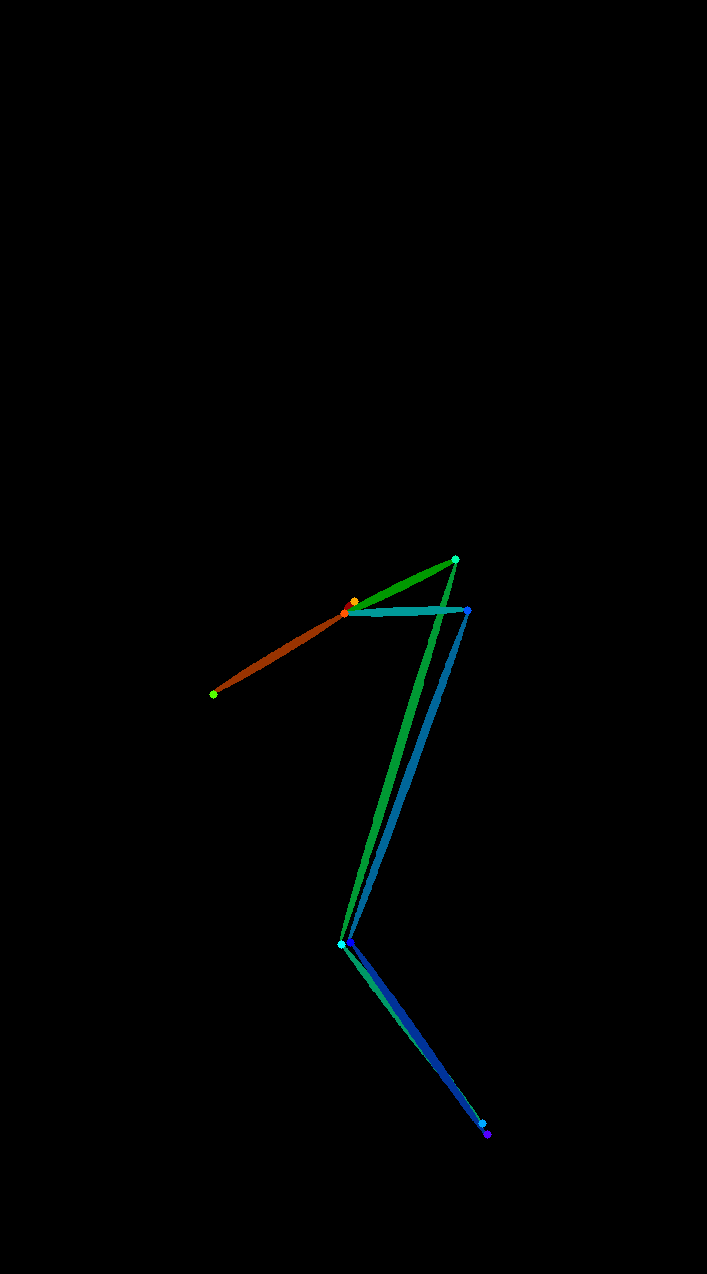

**결과 1 — 발레리나**

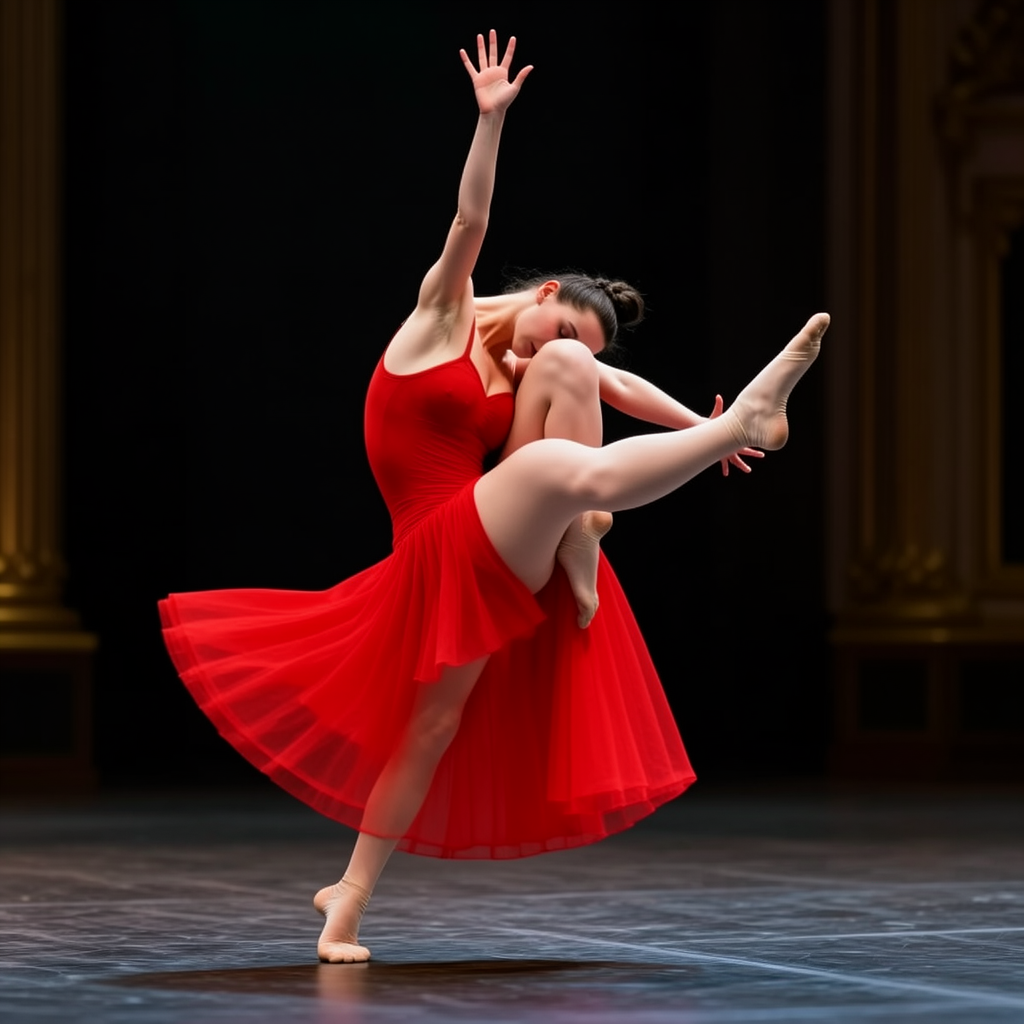

**결과 2 — 노년 남성**

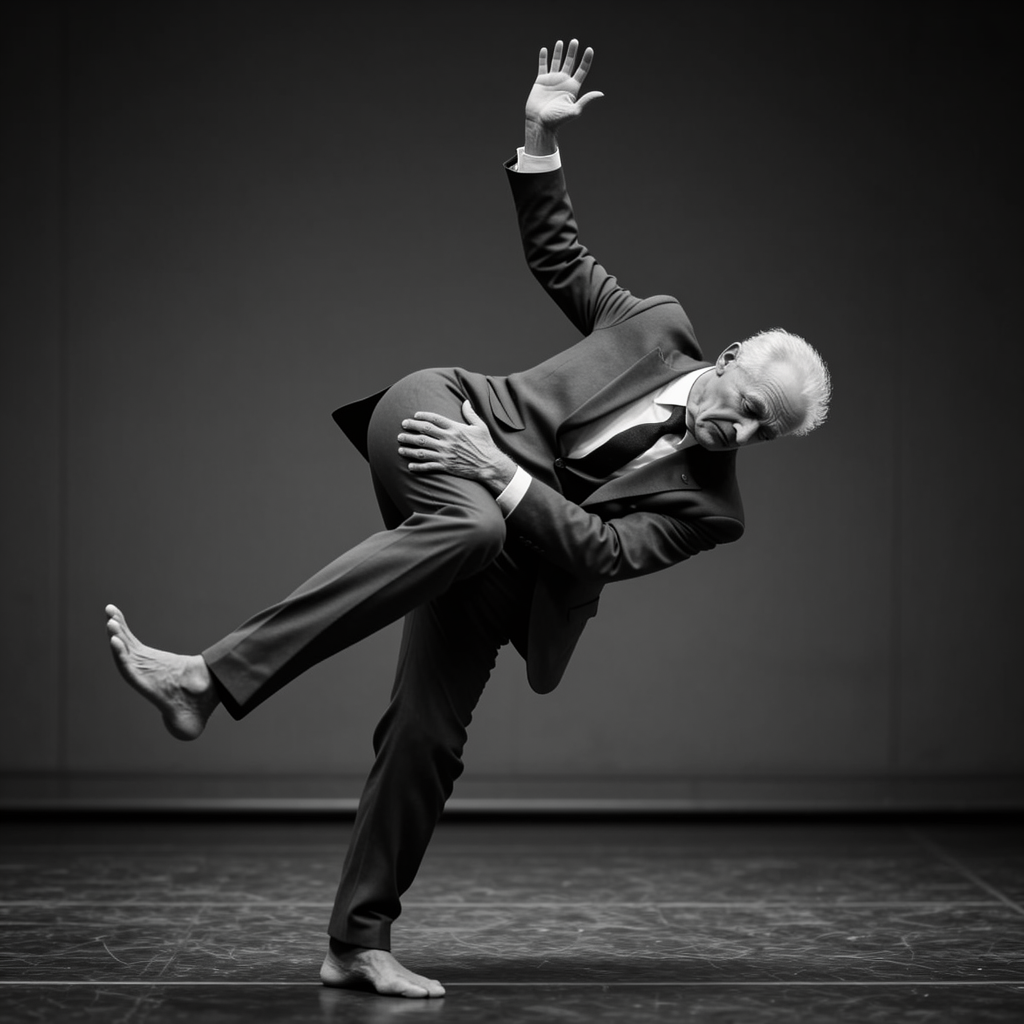

**결과 3 — 로봇**

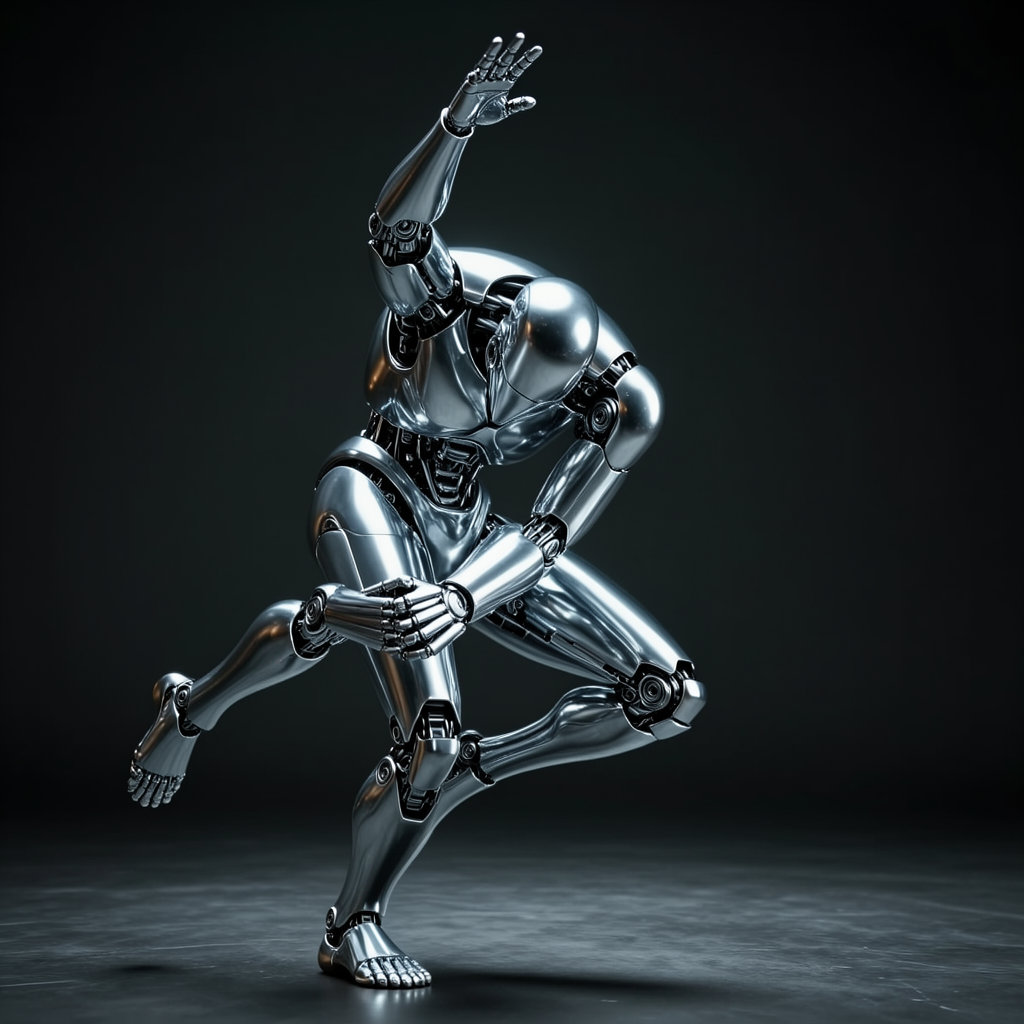

